### 1. Finance: House Prices - Advanced Regression Techniques
#### Dataset: House Prices - Advanced Regression Techniques

### Dataset Name:1. Finance: House Prices - Advanced Regression Techniques

### Description: This dataset contains various features of houses in Ames, Iowa, including sale prices.
#### Project Idea: Use linear regression to predict house prices based on features like square footage, number of bedrooms, and location. Start by exploring correlations between features and prices, then build a linear regression model to predict sale prices and evaluate its performance using metrics like RMSE. 

### 2) Import Libraries

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

### 2) Load the dataset

In [187]:
data = pd.read_csv('housing.csv')

In [189]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [191]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### 4) Data Exploration

In [194]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [196]:
data.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [198]:
# Fill missing values in total_bedrooms with the mean and assign it back
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].mean())


In [200]:
data.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [202]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [204]:
data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


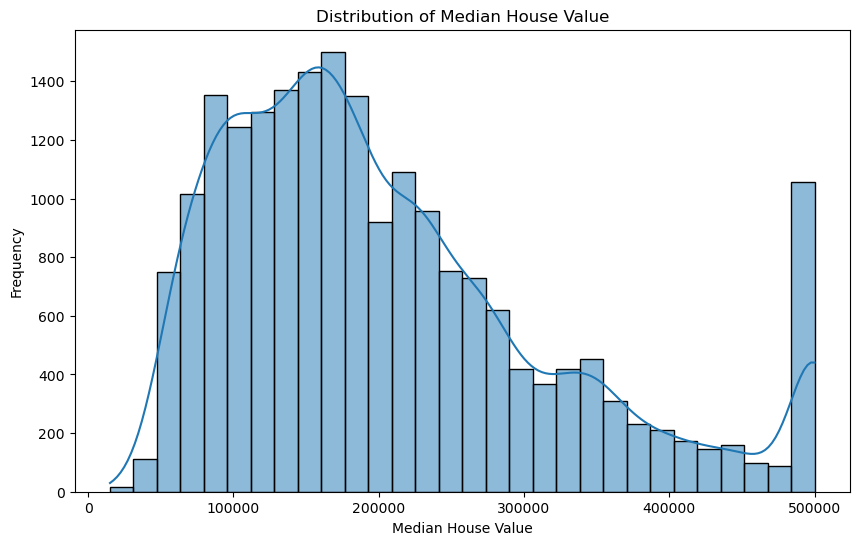

In [206]:
# Visualize the distribution of median house value
plt.figure(figsize=(10, 6))
sns.histplot(data['median_house_value'],bins = 30,kde = True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.show()

### observation :

#### Histogram: This graph displays the distribution of the median_house_value in your dataset.

#### X-axis (Median House Value): Represents the values of the median house prices.
#### Y-axis (Frequency): Represents the number of houses that fall into each price range (bin).

In [210]:
#Interpretation:

#Shape: If the histogram shows a right-skewed distribution (more houses priced lower), it suggests that while most houses are relatively affordable, there are some high-value outliers.
#Peaks: The highest peaks indicate the most common price ranges in dataset.

In [212]:
##error handling
#The error message "ValueError: could not convert string to float: 'NEAR BAY'" indicates that there is a categorical variable
#(specifically, the ocean_proximity column) that hasn't been properly converted to a numerical format before you tried to use it in calculations or modeling.

#Steps to Resolve the Issue
#One-Hot Encoding: Since ocean_proximity is a categorical variable with string values (like 'NEAR BAY', 'INLAND', etc.), you need to convert it to a numerical format using one-hot encoding.
#lets understand the below how to handle

## 5. Data reprocessing

### Convert ocean_proximity into numerical values using one-hot encoding

In [215]:
# Convert ocean_proximity into numerical values using one-hot encoding
data = pd.get_dummies(data, columns=['ocean_proximity'], drop_first=True)

# Prepare the feature set (X) and target variable (y)
X = data.drop('median_house_value', axis=1)
y = data['median_house_value']


In [217]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   longitude                   20640 non-null  float64
 1   latitude                    20640 non-null  float64
 2   housing_median_age          20640 non-null  float64
 3   total_rooms                 20640 non-null  float64
 4   total_bedrooms              20640 non-null  float64
 5   population                  20640 non-null  float64
 6   households                  20640 non-null  float64
 7   median_income               20640 non-null  float64
 8   median_house_value          20640 non-null  float64
 9   ocean_proximity_INLAND      20640 non-null  bool   
 10  ocean_proximity_ISLAND      20640 non-null  bool   
 11  ocean_proximity_NEAR BAY    20640 non-null  bool   
 12  ocean_proximity_NEAR OCEAN  20640 non-null  bool   
dtypes: bool(4), float64(9)
memory u

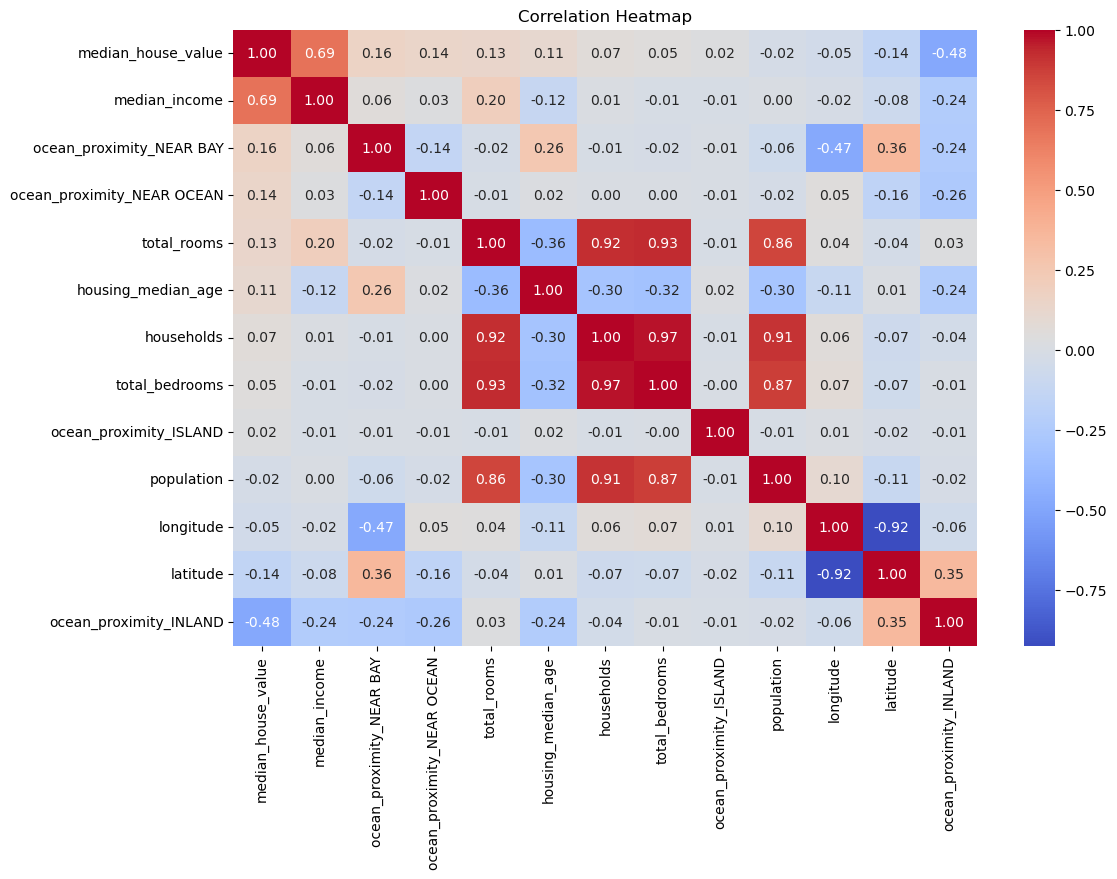

In [227]:
# Visualize correlations with median house value
plt.figure(figsize=(12, 8))
correlation = data.corr()['median_house_value'].sort_values(ascending=False)
sns.heatmap(data[correlation.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

### observation 

In [232]:
#correlation = data.corr()['median_house_value'].sort_values(ascending=False)
#This line calculates the correlation of all features in the dataset with the median_house_value.
#The result is sorted in descending order, meaning the features most positively correlated with house prices appear first.

In [234]:
#sns.heatmap(data[correlation.index].corr(), annot=True, cmap='coolwarm', fmt=".2f")
#annot=True means that the correlation values will be shown on the heatmap.
#The cmap='coolwarm' setting colors the heatmap, with one color representing positive correlations and another for negative correlations.

#Example
#If the correlation value is 0.123456, using fmt=".2f" will display it as 0.12 on the heatmap.
#If the value is -0.98765, it will be displayed as -0.99.

### Understanding Correlation:

In [ ]:
#The heatmap shows how different features in your dataset relate to the median_house_value. Correlation values range from -1 to 1:
#1 means a perfect positive correlation (as one increases, the other increases).
#-1 means a perfect negative correlation (as one increases, the other decreases).
#0 means no correlation (they don't affect each other).

In [ ]:
#Positive Correlation:
#Features like median_income, total_rooms, and households likely show strong positive correlations with median_house_value. This means that as these features increase, the house price tends to increase too.
    
#Negative Correlation:
#If any features (like housing_median_age) show a negative correlation, it indicates that as those values increase, the median house value tends to decrease.
    
#Strength of Correlation:
#The closer the correlation value is to +1 or -1, the stronger the relationship. Values around 0 suggest little to no correlation.

In [239]:
#Dark Red: Strong positive correlation
#Dark Blue: Strong negative correlation
#Light colors: Weak correlation

### 6. Split the Dataset

In [258]:
# Split the dataset into training and test sets
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2,random_state=42)

In [281]:
#train_test_split:
#This function from the sklearn.model_selection module is used to split arrays or matrices into random train and test subsets.

In [275]:
#Visualize Sample Data
#You can also visualize some samples from each set to ensure they contain different data:

In [277]:
x_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,-117.03,32.71,33.0,3126.0,627.0,2300.0,623.0,3.2596,False,False,False,True
8267,-118.16,33.77,49.0,3382.0,787.0,1314.0,756.0,3.8125,False,False,False,True
17445,-120.48,34.66,4.0,1897.0,331.0,915.0,336.0,4.1563,False,False,False,True
14265,-117.11,32.69,36.0,1421.0,367.0,1418.0,355.0,1.9425,False,False,False,True
2271,-119.80,36.78,43.0,2382.0,431.0,874.0,380.0,3.5542,True,False,False,False


In [279]:
x_train.shape

(16512, 12)

In [267]:
y_train.shape

(16512,)

In [271]:
 x_test.shape, y_test.shape

((4128, 12), (4128,))

In [273]:
y_train.head()

14196    103000.0
8267     382100.0
17445    172600.0
14265     93400.0
2271      96500.0
Name: median_house_value, dtype: float64

### 7. Model Training

In [286]:
# Create and train the linear regression model
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

### 8. Make Predictions

In [291]:
# Make predictions on the test set
y_pred = model.predict(x_test)


In [293]:
y_pred 

array([ 64629.45079786, 134799.34083606, 266063.38139054, ...,
       439180.98341181, 120797.55240621, 183386.04993584])

In [295]:
#This method uses the trained model to predict target values based on the feature data in the test set (X_test).
#The result of the prediction is stored in the variable y_pred. This will be an array of predicted values corresponding to the input features in X_test.

### 9. Evaluate the Model

Root Mean Squared Error (RMSE): 70031.42
R-squared (R2): 0.63


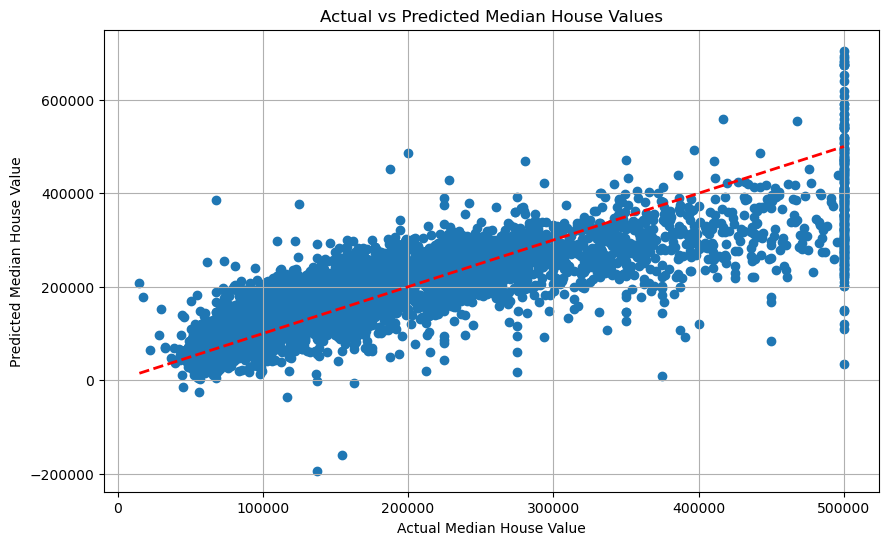

In [298]:
# Calculate evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predicted vs actual values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', lw=2)
plt.xlabel('Actual Median House Value')
plt.ylabel('Predicted Median House Value')
plt.title('Actual vs Predicted Median House Values')
plt.grid()
plt.show()


In [ ]:
#Model Evaluation: Calculate RMSE and R² to assess the model's performance.
#Visual Comparison: Create a scatter plot to compare actual and predicted house values.
#Expected Output
#Evaluation Metrics: The output will show RMSE and R² values, indicating how well the model performed.
#Scatter Plot: The scatter plot will visualize the relationship between actual and predicted values.

### Conclusion

In [ ]:
#This project guides you through predicting housing prices using linear regression with your dataset. 
#You explored the data, handled missing values, performed one-hot encoding, trained a model, and evaluated its performance